# El modelo nuevo frente a la Entrega 2

El profesor pidió para esta entrega un **modelo nuevo**, distinto de los de la Entrega 2 y no
explicado en clase, que **supere sus métricas**. Para que la comparación sea válida se hace sobre
la misma partición 80/20 con semilla 42, con la misma etiqueta (riesgo alto si `churn_probability`
supera su mediana, estimada solo con entrenamiento) y en la misma prueba de 9.745 clientes, y la
superación se confirma con pruebas estadísticas y no solo con la cifra puntual.

**El modelo elegido es la Explainable Boosting Machine (EBM)** de Lou, Caruana, Gehrke y Hooker
(2013), en la implementación `interpret` de Nori y otros (2019). No aparece en las notas del curso.
Es un modelo aditivo generalizado con interacciones por pares (GA²M):

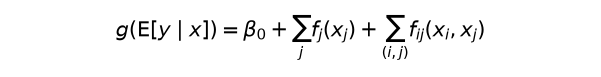

In [1]:
import matplotlib.pyplot as plt
# La fórmula se dibuja con mathtext para que se vea igual en cualquier visor de cuadernos.
fig, ax = plt.subplots(figsize=(7.5, 0.75))
ax.axis('off')
ax.text(0.5, 0.5, r'$g(\mathrm{E}[y \mid x]) = \beta_0 + \sum_j f_j(x_j) + \sum_{(i,j)} f_{ij}(x_i, x_j)$',
        ha='center', va='center', fontsize=15)
plt.show()

donde cada función de forma fⱼ se aprende por *boosting* cíclico de árboles de pocas hojas sobre
una sola variable a la vez, con una tasa de aprendizaje baja para que el orden de las variables no
importe, y se promedia sobre varias submuestras (bolsas externas). Reúne dos cosas que no suelen ir
juntas: la flexibilidad del *boosting* para captar efectos no lineales y la legibilidad de un modelo
aditivo, en el que la contribución de cada variable es una curva que se puede graficar. Esa
combinación responde a la causa del bajo desempeño de la Entrega 2, que fue la no linealidad.

**Protocolo.** Los modelos de la Entrega 2 se reentrenan con los hiperparámetros que eligió su
`GridSearchCV` (regresión logística L1 con C = 0,1; Lasso con alpha = 1e-4). La EBM y, como
referencia, XGBoost —el mejor modelo visto en clase en las 140 corridas— se afinan con el mismo
protocolo: optimización bayesiana (Optuna, TPE) con el presupuesto de las 140 corridas y validación
cruzada de 5 pliegues sobre el entrenamiento (los mismos 5 pliegues de la Entrega 2), y reajuste
final sobre todo el entrenamiento. Cada modelo toca la prueba una sola vez. El cálculo lo hace
`comparar_entrega2.py`, y aquí se cargan sus modelos y predicciones para repetir los contrastes.

In [2]:
import json
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src import analisis, comparacion, datos, graficos
from src import estadistica as est
from src.formato import dec, ent, enumerar, intervalo, p_valor, pct
from src.preprocesamiento import nombres_variables

graficos.estilo()
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

CARPETA = RAIZ / 'resultados' / 'comparacion_entrega2'
busquedas = json.loads((CARPETA / 'busquedas.json').read_text(encoding='utf-8'))
pred = pd.read_parquet(CARPETA / 'predicciones.parquet')
modelos_cmp = {k: joblib.load(CARPETA / 'modelos' / f'{k.replace("/", "__")}.joblib') for k in busquedas['modelos']}
NOMBRE = {'logistica_e2': 'Logística L1 (Entrega 2)', 'lasso_e2': 'Lasso (Entrega 2)',
          'xgboost': 'XGBoost (clase)', 'ebm': 'EBM (modelo nuevo)'}
p_med = datos.preparar_todo(metodo_etiqueta='mediana')      # misma partición y etiqueta de la Entrega 2
c = p_med['conjuntos']
assert c.X_test.index.sort_values().equals(pred.index), 'las predicciones no corresponden a esta prueba'
print(f'entrenamiento: {ent(busquedas["n_train"])} clientes · prueba: {ent(busquedas["n_test"])} · '
      f'umbral de la mediana (solo entrenamiento): {busquedas["etiqueta"]["umbral"]:.6f} · '
      f'riesgo alto en prueba: {pred["y_bin"].mean():.2%}')

entrenamiento: 38.978 clientes · prueba: 9.745 · umbral de la mediana (solo entrenamiento): 0.353972 · riesgo alto en prueba: 49.91%


## 1. La Entrega 2 se reproduce exactamente

Antes de comparar hay que asegurarse de que el punto de partida es el mismo: los modelos de la
Entrega 2, reentrenados con este código, deben dar las cifras de prueba que se publicaron.

In [3]:
filas = []
for tarea, nombre in (('clasificacion', 'logistica_e2'), ('regresion', 'lasso_e2')):
    for metrica, v in busquedas['modelos'][f'{tarea}/{nombre}']['reproduccion'].items():
        filas.append({'modelo': NOMBRE[nombre], 'métrica': metrica, 'publicado en la Entrega 2': v['publicado'],
                      'obtenido ahora': v['obtenido'], 'coincide': v['coincide']})
reproduccion = pd.DataFrame(filas)
reproduccion

,modelo,métrica,publicado en la Entrega 2,obtenido ahora,coincide
0,Logística L1 (Entrega 2),auc,0.6832,0.6832,True
1,Logística L1 (Entrega 2),recall,0.6515,0.6515,True
2,Lasso (Entrega 2),r2,0.1511,0.1511,True
3,Lasso (Entrega 2),rmse,0.0617,0.0617,True


## 2. Métricas de prueba

In [4]:
def tabla_metricas(tarea):
    filas = []
    for k, info in busquedas['modelos'].items():
        t, nombre = k.split('/')
        if t != tarea:
            continue
        filas.append({'modelo': NOMBRE[nombre], 'papel': info['papel'], 'CV media (entrenamiento)': info['cv_media'],
                      'CV desv.': info['cv_desv'], **info['prueba']})
    return pd.DataFrame(filas).set_index('modelo')

metricas_clf = tabla_metricas('clasificacion')
metricas_reg = tabla_metricas('regresion')
display(metricas_clf)
display(metricas_reg)

,papel,CV media (entrenamiento),CV desv.,accuracy,precision,recall,f1,auc,brier
modelo,,,,,,,,,
Logística L1 (Entrega 2),Entrega 2,0.6824,0.0043,0.6360,0.6311,0.6515,0.6412,0.6832,0.2245
XGBoost (clase),mejor modelo de clase en las 140 corridas,0.7232,0.0035,0.6724,0.6845,0.6375,0.6602,0.7206,0.2069
EBM (modelo nuevo),"modelo nuevo, no visto en clase",0.7221,0.0030,0.6704,0.6745,0.6565,0.6653,0.7187,0.2096


,papel,CV media (entrenamiento),CV desv.,rmse,mae,r2
modelo,,,,,,
Lasso (Entrega 2),Entrega 2,0.0618,0.0005,0.0617,0.0507,0.1511
XGBoost (clase),mejor modelo de clase en las 140 corridas,0.0590,0.0004,0.0592,0.0471,0.2177
EBM (modelo nuevo),"modelo nuevo, no visto en clase",0.0590,0.0004,0.0593,0.0472,0.2159


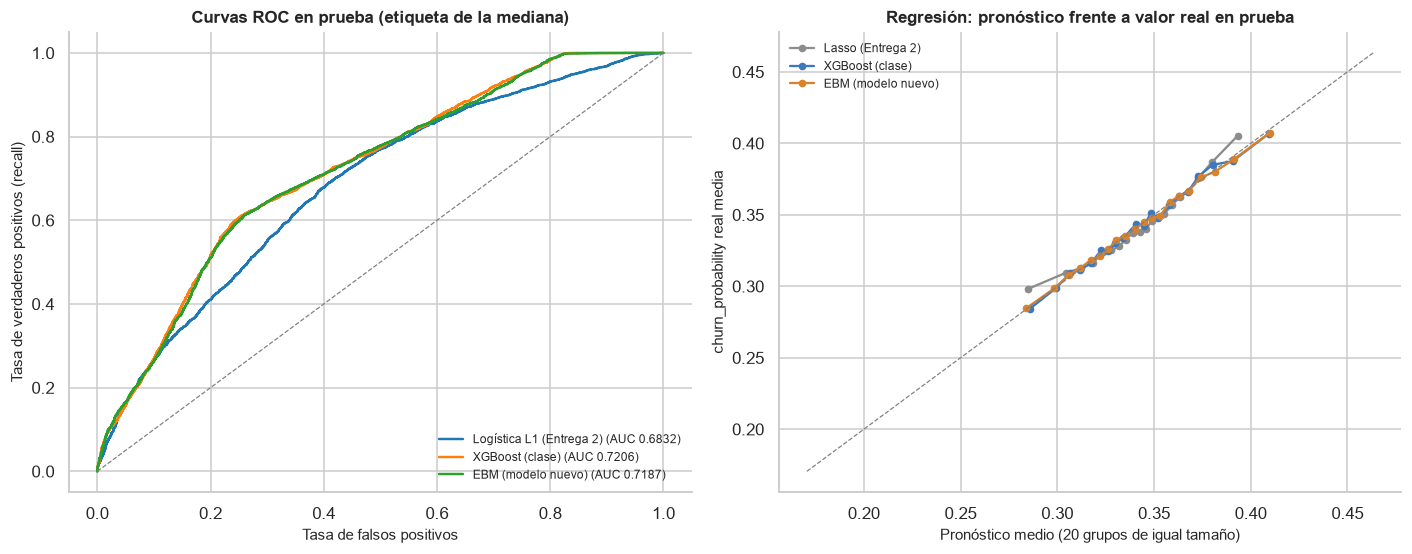

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))
graficos.curvas_roc(pred['y_bin'], {NOMBRE[m]: pred[f'clf_{m}'] for m in ('logistica_e2', 'xgboost', 'ebm')},
                    ax=ax[0], titulo='Curvas ROC en prueba (etiqueta de la mediana)')
for m, color in (('lasso_e2', '#8c8c8c'), ('xgboost', '#3d78bf'), ('ebm', '#d9822b')):
    orden = np.argsort(pred[f'reg_{m}'].to_numpy())
    grupos = np.array_split(orden, 20)
    ax[1].plot([pred[f'reg_{m}'].to_numpy()[g].mean() for g in grupos],
               [pred['y_cont'].to_numpy()[g].mean() for g in grupos], marker='o', ms=4, color=color, label=NOMBRE[m])
lim = [pred['y_cont'].quantile(0.01), pred['y_cont'].quantile(0.99)]
ax[1].plot(lim, lim, ls='--', color='grey', lw=0.8)
ax[1].set_xlabel('Pronóstico medio (20 grupos de igual tamaño)')
ax[1].set_ylabel('churn_probability real media')
ax[1].set_title('Regresión: pronóstico frente a valor real en prueba')
ax[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 3. Clasificación: DeLong, bootstrap y delta de Cliff

Para cada pareja (referencia, candidato) se reporta la diferencia de AUC del candidato con su
intervalo de DeLong y su intervalo bootstrap BCa (2.000 réplicas estratificadas por clase), el
p-valor de DeLong, ajustado por Holm sobre las tres comparaciones, y el delta de Cliff entre los AUC
de los 5 pliegues de validación cruzada del entrenamiento (+1: el candidato gana en todos).

In [6]:
puntajes = {m: pred[f'clf_{m}'].to_numpy() for m in ('logistica_e2', 'xgboost', 'ebm')}
pliegues_auc = {m: busquedas['modelos'][f'clasificacion/{m}']['pliegues'] for m in puntajes}
pares = [('logistica_e2', 'ebm'), ('logistica_e2', 'xgboost'), ('xgboost', 'ebm')]
contraste_clf = comparacion.contrastar_clasificacion(pred['y_bin'], puntajes, pares, pliegues_auc)
contraste_clf.assign(referencia=contraste_clf['referencia'].map(NOMBRE),
                     candidato=contraste_clf['candidato'].map(NOMBRE))[
    ['referencia', 'candidato', 'auc_referencia', 'auc_candidato', 'diferencia', 'ic_delong_inf', 'ic_delong_sup',
     'ic_bca_inf', 'ic_bca_sup', 'z', 'p_delong', 'p_delong_ajustado', 'correlacion_auc', 'delta_cliff']]

,referencia,candidato,auc_referencia,auc_candidato,diferencia,ic_delong_inf,ic_delong_sup,ic_bca_inf,ic_bca_sup,z,p_delong,p_delong_ajustado,correlacion_auc,delta_cliff
0,Logística L1 (Entrega 2),EBM (modelo nuevo),0.6832,0.7187,0.0355,0.0278,0.0432,0.0281,0.0434,9.0182,0.0000,0.0000,0.7177,1.0000
1,Logística L1 (Entrega 2),XGBoost (clase),0.6832,0.7206,0.0374,0.0301,0.0447,0.0303,0.0449,10.0609,0.0000,0.0000,0.7473,1.0000
2,XGBoost (clase),EBM (modelo nuevo),0.7206,0.7187,-0.0019,-0.0049,0.0010,-0.0051,0.0009,-1.2936,0.1958,0.1958,0.9569,-0.1200


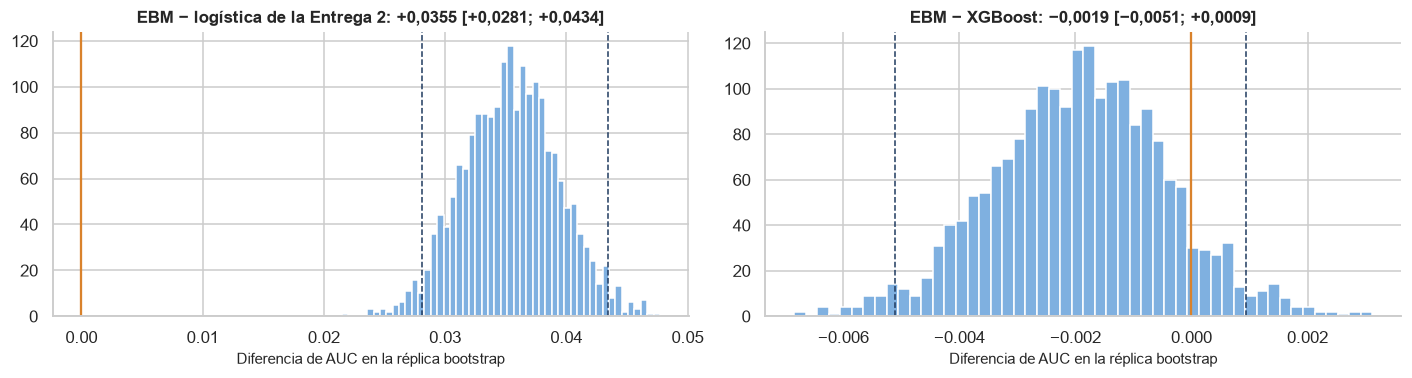

In [7]:
boot = est.bootstrap_auc(pred['y_bin'], puntajes['logistica_e2'], puntajes['ebm'])
boot_x = est.bootstrap_auc(pred['y_bin'], puntajes['xgboost'], puntajes['ebm'])
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for a, b, titulo in ((ax[0], boot, 'EBM − logística de la Entrega 2'), (ax[1], boot_x, 'EBM − XGBoost')):
    a.hist(b['replicas'], bins=50, color='#7fb0e0', edgecolor='white')
    for v in b['ic_bca']:
        a.axvline(v, color=graficos.AZUL, ls='--', lw=1)
    a.axvline(0, color='#d9822b', lw=1.5)
    a.set_title(f'{titulo}: {dec(b["estimacion"], 4, True)} {intervalo(*b["ic_bca"], d=4, signo=True)}')
    a.set_xlabel('Diferencia de AUC en la réplica bootstrap')
plt.tight_layout()
plt.show()

In [8]:
fe = contraste_clf.iloc[0]
fx = contraste_clf.iloc[2]
mc = metricas_clf
display(Markdown(f"""
**La EBM supera a la Entrega 2 en clasificación.** Su AUC de prueba es {dec(fe['auc_candidato'])}, frente a
{dec(fe['auc_referencia'])} de la logística L1: una mejora de {dec(fe['diferencia'], 4, True)} con intervalo BCa al
95 % {intervalo(fe['ic_bca_inf'], fe['ic_bca_sup'], signo=True)}, que no se acerca a cero. DeLong la confirma
(z = {dec(fe['z'], 2)}, {p_valor(fe['p_delong'])}; ajustado por Holm, {p_valor(fe['p_delong_ajustado'])}), y la EBM supera a
la logística en {'los 5' if fe['delta_cliff'] == 1 else 'la mayoría de los'} pliegues de validación (delta de Cliff
{dec(fe['delta_cliff'], 2, True)}). También mejora el recall con el umbral de 0,5, la otra métrica que reportó la
Entrega 2: {dec(mc.loc[NOMBRE['ebm'], 'recall'])} frente a {dec(mc.loc[NOMBRE['logistica_e2'], 'recall'])}.

Frente a XGBoost, el mejor modelo de clase, la EBM queda en {dec(fx['diferencia'], 4, True)} de AUC
{intervalo(fx['ic_bca_inf'], fx['ic_bca_sup'], signo=True)}, sin diferencia significativa (DeLong
{p_valor(fx['p_delong'])}): **empata con el mejor modelo de caja negra siendo un modelo legible.** La
correlación de {dec(fx['correlacion_auc'], 2)} entre sus AUC indica que ordenan a los clientes casi igual.
"""))


**La EBM supera a la Entrega 2 en clasificación.** Su AUC de prueba es 0,7187, frente a
0,6832 de la logística L1: una mejora de +0,0355 con intervalo BCa al
95 % [+0,0281; +0,0434], que no se acerca a cero. DeLong la confirma
(z = 9,02, p < 10⁻¹⁸; ajustado por Holm, p < 10⁻¹⁸), y la EBM supera a
la logística en los 5 pliegues de validación (delta de Cliff
+1,00). También mejora el recall con el umbral de 0,5, la otra métrica que reportó la
Entrega 2: 0,6565 frente a 0,6515.

Frente a XGBoost, el mejor modelo de clase, la EBM queda en −0,0019 de AUC
[−0,0051; +0,0009], sin diferencia significativa (DeLong
p = 0,196): **empata con el mejor modelo de caja negra siendo un modelo legible.** La
correlación de 0,96 entre sus AUC indica que ordenan a los clientes casi igual.


## 4. Regresión: Diebold-Mariano, bootstrap estacionario y d de Cohen

Para la regresión se compara la pérdida cuadrática de cada cliente de prueba. Diebold-Mariano con
la corrección de Harvey, Leybourne y Newbold (HLN) contrasta si la diferencia media de pérdidas es
cero; el bootstrap estacionario repite el contraste sin suponer normalidad y respetando la
dependencia entre filas vecinas (las filas se toman en el orden original del archivo de clientes,
que está organizado por bloques). La d de Cohen pareada mide el tamaño del efecto por cliente y la
d entre pliegues, su estabilidad.

In [9]:
pron = {m: pred[f'reg_{m}'].to_numpy() for m in ('lasso_e2', 'xgboost', 'ebm')}
pliegues_rmse = {m: busquedas['modelos'][f'regresion/{m}']['pliegues'] for m in pron}
pares_r = [('lasso_e2', 'ebm'), ('lasso_e2', 'xgboost'), ('xgboost', 'ebm')]
contraste_reg = comparacion.contrastar_regresion(pred['y_cont'], pron, pares_r, pliegues_rmse)
contraste_reg.assign(referencia=contraste_reg['referencia'].map(NOMBRE),
                     candidato=contraste_reg['candidato'].map(NOMBRE))[
    ['referencia', 'candidato', 'mejora_r2', 'mejora_r2_ic_inf', 'mejora_r2_ic_sup', 'mejora_rmse',
     'mejora_rmse_ic_inf', 'mejora_rmse_ic_sup', 'dm_hln', 'p_dm', 'p_dm_ajustado', 'p_dm_absoluta', 'bloque',
     'p_bootstrap_estacionario', 'd_cohen_z', 'd_cohen_pliegues']]

,referencia,candidato,mejora_r2,mejora_r2_ic_inf,mejora_r2_ic_sup,mejora_rmse,mejora_rmse_ic_inf,mejora_rmse_ic_sup,dm_hln,p_dm,p_dm_ajustado,p_dm_absoluta,bloque,p_bootstrap_estacionario,d_cohen_z,d_cohen_pliegues
0,Lasso (Entrega 2),EBM (modelo nuevo),0.0648,0.0551,0.0738,0.0024,0.0020,0.0027,13.3280,0.0000,0.0000,0.0000,2.3781,0.0000,0.1350,6.0549
1,Lasso (Entrega 2),XGBoost (clase),0.0666,0.0571,0.0753,0.0025,0.0021,0.0028,14.0542,0.0000,0.0000,0.0000,2.4395,0.0000,0.1424,6.3028
2,XGBoost (clase),EBM (modelo nuevo),-0.0017,-0.0036,0.0003,-0.0001,-0.0001,0.0000,-1.7877,0.0739,0.0739,0.0121,2.4989,0.0765,-0.0181,-0.1453


In [10]:
ge, gx = contraste_reg.iloc[0], contraste_reg.iloc[2]
mr = metricas_reg
display(Markdown(f"""
**La EBM también supera a la Entrega 2 en regresión.** Su R² de prueba es {dec(mr.loc[NOMBRE['ebm'], 'r2'])}, frente
a {dec(mr.loc[NOMBRE['lasso_e2'], 'r2'])} del Lasso: {dec(ge['mejora_r2'], 4, True)} {intervalo(ge['mejora_r2_ic_inf'], ge['mejora_r2_ic_sup'], signo=True)}, y su
RMSE baja de {dec(mr.loc[NOMBRE['lasso_e2'], 'rmse'], 5)} a {dec(mr.loc[NOMBRE['ebm'], 'rmse'], 5)}. Diebold-Mariano con HLN
da {dec(ge['dm_hln'], 2)} ({p_valor(ge['p_dm'])}; con Holm, {p_valor(ge['p_dm_ajustado'])}); con pérdida absoluta,
{p_valor(ge['p_dm_absoluta'])}; y el bootstrap estacionario, con bloques de longitud media {dec(ge['bloque'], 1)},
{p_valor(ge['p_bootstrap_estacionario'])}. La d de Cohen por cliente es {dec(ge['d_cohen_z'], 3)}: la mejora de
un cliente concreto es pequeña frente al ruido de su pérdida, pero se repite en todos los pliegues
(d entre pliegues {dec(ge['d_cohen_pliegues'], 1)}).

Frente a XGBoost, la EBM queda en {dec(gx['mejora_r2'], 4, True)} de R², sin diferencia significativa
(Diebold-Mariano {p_valor(gx['p_dm'])}; bootstrap estacionario {p_valor(gx['p_bootstrap_estacionario'])}).
"""))


**La EBM también supera a la Entrega 2 en regresión.** Su R² de prueba es 0,2159, frente
a 0,1511 del Lasso: +0,0648 [+0,0551; +0,0738], y su
RMSE baja de 0,06166 a 0,05926. Diebold-Mariano con HLN
da 13,33 (p < 10⁻³⁹; con Holm, p < 10⁻³⁹); con pérdida absoluta,
p < 10⁻⁹³; y el bootstrap estacionario, con bloques de longitud media 2,4,
p < 0,001. La d de Cohen por cliente es 0,135: la mejora de
un cliente concreto es pequeña frente al ruido de su pérdida, pero se repite en todos los pliegues
(d entre pliegues 6,1).

Frente a XGBoost, la EBM queda en −0,0017 de R², sin diferencia significativa
(Diebold-Mariano p = 0,074; bootstrap estacionario p = 0,076).


## 5. Por qué falló la Entrega 2 y qué aprende la EBM

La EBM permite ver la contribución de cada variable. Las gráficas comparan la función de forma de la
EBM con el efecto que la logística L1 de la Entrega 2 asigna a la misma variable, en la misma escala
(contribución al logit, centrada). Se muestran las cuatro variables que concentran la señal según
el análisis de variables del Entregable 3.

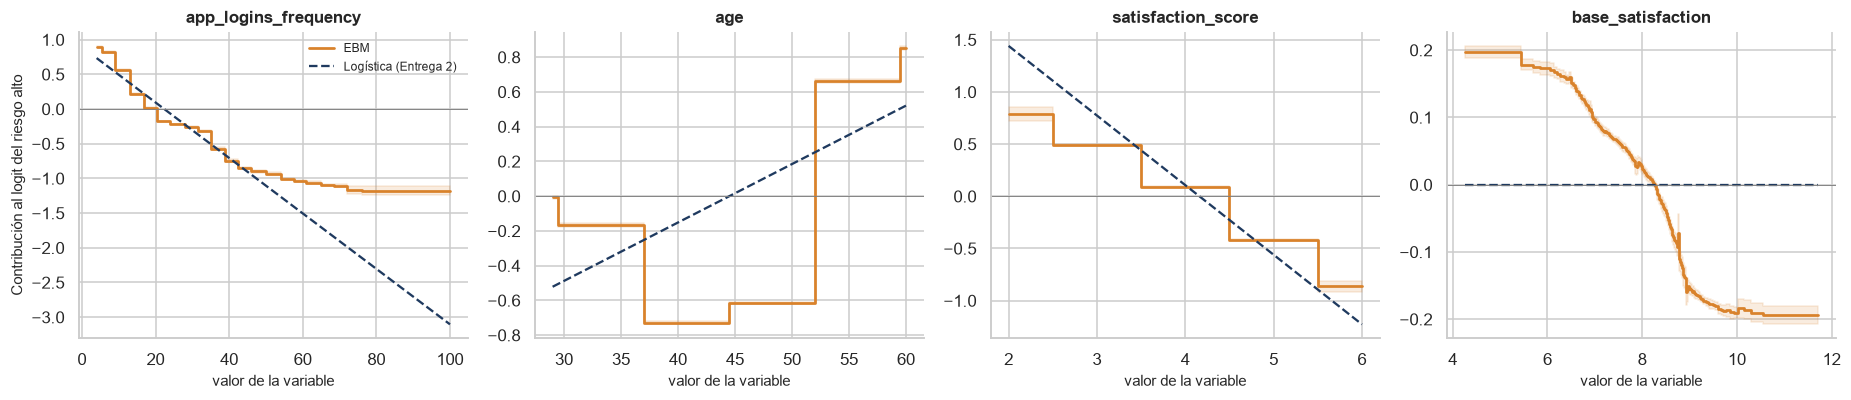

In [11]:
ebm_clf = modelos_cmp['clasificacion/ebm']
log_clf = modelos_cmp['clasificacion/logistica_e2']
variables = ['app_logins_frequency', 'age', 'satisfaction_score', 'base_satisfaction']
fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
for a, v in zip(ax, variables):
    f = analisis.forma_ebm(ebm_clf, v)
    x = np.r_[f['desde'].iloc[0], f['hasta']]
    a.step(x, np.r_[f['efecto'], f['efecto'].iloc[-1]], where='post', color='#d9822b', lw=1.8, label='EBM')
    a.fill_between(x, np.r_[f['inf'], f['inf'].iloc[-1]], np.r_[f['sup'], f['sup'].iloc[-1]], step='post',
                   color='#d9822b', alpha=0.15)
    xs = np.linspace(x[0], x[-1], 100)
    a.plot(xs, analisis.efecto_lineal(log_clf, v, xs), color=graficos.AZUL, lw=1.5, ls='--', label='Logística (Entrega 2)')
    a.axhline(0, color='grey', lw=0.6)
    a.set_title(v)
    a.set_xlabel('valor de la variable')
ax[0].set_ylabel('Contribución al logit del riesgo alto')
ax[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
ebm_modelo = ebm_clf.named_steps['modelo'].ebm_
importancia = pd.Series(ebm_modelo.term_importances(), index=[
    ' × '.join(nombres_variables(ebm_clf.named_steps['preprocesado'])[j] for j in t)
    for t in ebm_modelo.term_features_]).sort_values(ascending=False)
cuota = importancia / importancia.sum()
display(cuota.head(10).to_frame('cuota de la importancia total'))
pares_ebm = [t for t in importancia.index if ' × ' in t]

# Ablación: la misma EBM sin interacciones (GAM puro), reentrenada sobre el entrenamiento.
from sklearn.base import clone
gam = clone(ebm_clf).set_params(modelo__interactions=0).fit(c.X_train, p_med['y_train'])
puntaje_gam = gam.predict_proba(c.X_test.loc[pred.index])[:, 1]
ablacion = est.delong(pred['y_bin'], puntaje_gam, puntajes['ebm'])
sin_ablacion = est.delong(pred['y_bin'], puntajes['logistica_e2'], puntaje_gam)
nombres_pre = nombres_variables(log_clf.named_steps['preprocesado'])
coef_log = pd.Series(np.ravel(log_clf.named_steps['modelo'].coef_), index=nombres_pre)
anuladas = [v for v in variables if coef_log[v] == 0]
f_age = analisis.forma_ebm(ebm_clf, 'age')
display(Markdown(f"""
Las cuatro variables acumulan el {pct(cuota.reindex(variables).sum(), 0)} de la importancia de la EBM
(media del valor absoluto de cada término sobre el entrenamiento), y sus efectos no son lineales:
la EBM aprende tramos y mesetas que una recta no puede representar. El efecto de la edad, por
ejemplo, no es monótono: va de {dec(f_age['efecto'].min(), 2)} a {dec(f_age['efecto'].max(), 2)} en la escala del
logit, mientras que la logística solo puede asignarle una pendiente. La frecuencia de uso de la
aplicación deja de reducir el riesgo a partir de cierto nivel, pero la recta sigue bajando y
exagera el efecto en los usuarios más activos.{' La penalización L1 de la Entrega 2 anuló ' + enumerar(f'`{v}`' for v in anuladas) + (', que en la EBM tiene' if len(anuladas) == 1 else ', que en la EBM tienen') + ' un efecto claro y no lineal.' if anuladas else ''}

Las {len(pares_ebm)} interacciones por pares que eligió la EBM reúnen el {pct(cuota.reindex(pares_ebm).sum(), 1)} de la
importancia, pero aportan poco a la discriminación: una EBM idéntica sin interacciones (un modelo
aditivo puro) obtiene {dec(ablacion['auc_a'])} de AUC en prueba, frente a {dec(ablacion['auc_b'])} de la EBM completa
(DeLong {p_valor(ablacion['p_bilateral'])}), y por sí sola ya supera a la Entrega 2 en
{dec(sin_ablacion['diferencia'], 4, True)} (DeLong {p_valor(sin_ablacion['p_bilateral'])}). Lo que faltaba en la Entrega 2 era,
sobre todo, flexibilidad en cada variable.
"""))

,cuota de la importancia total
age,0.2418
app_logins_frequency,0.1797
satisfaction_score,0.1031
app_logins_frequency × satisfaction_score,0.0768
age × app_logins_frequency,0.0721
age × base_satisfaction,0.0425
base_satisfaction,0.0419
app_logins_frequency × base_satisfaction,0.0361
age × satisfaction_score,0.0279
income_bracket_Low,0.0131



Las cuatro variables acumulan el 57 % de la importancia de la EBM
(media del valor absoluto de cada término sobre el entrenamiento), y sus efectos no son lineales:
la EBM aprende tramos y mesetas que una recta no puede representar. El efecto de la edad, por
ejemplo, no es monótono: va de −0,73 a 0,85 en la escala del
logit, mientras que la logística solo puede asignarle una pendiente. La frecuencia de uso de la
aplicación deja de reducir el riesgo a partir de cierto nivel, pero la recta sigue bajando y
exagera el efecto en los usuarios más activos. La penalización L1 de la Entrega 2 anuló `base_satisfaction`, que en la EBM tiene un efecto claro y no lineal.

Las 5 interacciones por pares que eligió la EBM reúnen el 25,5 % de la
importancia, pero aportan poco a la discriminación: una EBM idéntica sin interacciones (un modelo
aditivo puro) obtiene 0,7185 de AUC en prueba, frente a 0,7187 de la EBM completa
(DeLong p = 0,910), y por sí sola ya supera a la Entrega 2 en
+0,0353 (DeLong p < 10⁻²¹). Lo que faltaba en la Entrega 2 era,
sobre todo, flexibilidad en cada variable.


## 6. El techo de información

¿Cuánto más se puede mejorar? `active_products` determina casi por completo el objetivo (se excluyó
como predictor porque la etiqueta se construyó a partir de ella), y no se relaciona con las demás
variables. Un modelo *oráculo* que la conoce explica casi toda la varianza; si se promedia su
pronóstico sobre la distribución de `active_products` del entrenamiento, se obtiene el mejor
pronóstico posible **sin** conocerla. Esa cifra es el techo de cualquier modelo que use solo las
variables permitidas. Se calcula aquí sobre la misma prueba, con un *gradient boosting* de
histogramas como oráculo (la variable solo se usa para entrenarlo).

In [13]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, roc_auc_score

pre = comparacion.pipeline_entrega2('regresion', c.X_train).named_steps['preprocesado'].fit(c.X_train)
ap = p_med['df']['active_products']
Xtr_o = np.column_stack([pre.transform(c.X_train), ap.loc[c.X_train.index]])
oraculo = HistGradientBoostingRegressor(learning_rate=0.05, max_iter=600, random_state=42).fit(Xtr_o, c.y_train_cont)
X_te_o = pre.transform(c.X_test.loc[pred.index])
r2_oraculo = r2_score(pred['y_cont'], oraculo.predict(np.column_stack([X_te_o, ap.loc[pred.index]])))
niveles, cuentas = np.unique(ap.loc[c.X_train.index], return_counts=True)
techo = sum(w * oraculo.predict(np.column_stack([X_te_o, np.full(len(X_te_o), k)]))
            for k, w in zip(niveles, cuentas / cuentas.sum()))
techo_auc, techo_r2 = roc_auc_score(pred['y_bin'], techo), r2_score(pred['y_cont'], techo)
(CARPETA / 'techo.json').write_text(json.dumps({'auc_mediana': techo_auc, 'r2': techo_r2, 'r2_oraculo': r2_oraculo}),
                                    encoding='utf-8')
resumen_techo = pd.DataFrame({
    'AUC (mediana)': [metricas_clf.loc[NOMBRE['logistica_e2'], 'auc'], metricas_clf.loc[NOMBRE['xgboost'], 'auc'],
                      metricas_clf.loc[NOMBRE['ebm'], 'auc'], techo_auc],
    'R²': [metricas_reg.loc[NOMBRE['lasso_e2'], 'r2'], metricas_reg.loc[NOMBRE['xgboost'], 'r2'],
           metricas_reg.loc[NOMBRE['ebm'], 'r2'], techo_r2]},
    index=['Entrega 2', 'XGBoost (clase)', 'EBM (modelo nuevo)', 'Techo: oráculo marginalizado'])
resumen_techo['fracción del techo (AUC − 0,5)'] = (resumen_techo['AUC (mediana)'] - 0.5) / (techo_auc - 0.5)
resumen_techo['fracción del techo (R²)'] = resumen_techo['R²'] / techo_r2
resumen_techo

,AUC (mediana),R²,"fracción del techo (AUC − 0,5)",fracción del techo (R²)
Entrega 2,0.6832,0.1511,0.8241,0.6877
XGBoost (clase),0.7206,0.2177,0.9925,0.9906
EBM (modelo nuevo),0.7187,0.2159,0.9838,0.9826
Techo: oráculo marginalizado,0.7223,0.2197,1.0000,1.0000


In [14]:
display(Markdown(f"""
Con `active_products` el oráculo alcanza un R² de {dec(r2_oraculo, 4)} en prueba. Sin ella, el techo es de
**{dec(techo_auc, 4)} de AUC y {dec(techo_r2, 4)} de R²**. La Entrega 2 cubría el
{pct(resumen_techo.loc['Entrega 2', 'fracción del techo (AUC − 0,5)'], 0)} de la discriminación alcanzable
(medida como AUC − 0,5) y el {pct(resumen_techo.loc['Entrega 2', 'fracción del techo (R²)'], 0)} del R² alcanzable; la EBM
llega al {pct(resumen_techo.loc['EBM (modelo nuevo)', 'fracción del techo (AUC − 0,5)'], 0)} y al
{pct(resumen_techo.loc['EBM (modelo nuevo)', 'fracción del techo (R²)'], 0)}. Queda, por tanto, muy poco margen: ningún modelo,
por complejo que sea, puede superar esas cifras con las variables disponibles, y por eso la EBM y
XGBoost terminan empatados a pocas milésimas del techo.
"""))


Con `active_products` el oráculo alcanza un R² de 0,9994 en prueba. Sin ella, el techo es de
**0,7223 de AUC y 0,2197 de R²**. La Entrega 2 cubría el
82 % de la discriminación alcanzable
(medida como AUC − 0,5) y el 69 % del R² alcanzable; la EBM
llega al 98 % y al
98 %. Queda, por tanto, muy poco margen: ningún modelo,
por complejo que sea, puede superar esas cifras con las variables disponibles, y por eso la EBM y
XGBoost terminan empatados a pocas milésimas del techo.


## 7. La EBM dentro del pipeline combinatorio

Además de la comparación anterior, la EBM se integró en el pipeline de la guía como octavo modelo,
con la etiqueta del percentil 75 y la misma validación anidada: 4 balanceos × 4 optimizadores en
clasificación y 4 optimizadores en regresión. `class_weight` se implementa con pesos por fila,
porque la librería no lo ofrece, y se aplica multi-fidelidad (2 bolsas externas durante la búsqueda
y 8 en el modelo final).

In [15]:
tabla = analisis.cargar_tabla()
ebm_filas = tabla[(tabla['modelo'] == 'ebm') & (tabla['estado'] == 'ok')]
if ebm_filas.empty:
    display(Markdown('*Las corridas de la EBM en el pipeline todavía no han terminado.*'))
else:
    resumen = []
    for tarea in ('clasificacion', 'regresion'):
        mej = analisis.mejores_por_modelo(tabla, tarea)
        resumen.append(mej.assign(tarea=tarea)[['tarea', 'modelo', 'balanceo', 'optimizador', 'metrica', 'desv_ext']])
    display(pd.concat(resumen).set_index(['tarea', 'modelo']))
    display(ebm_filas.pivot_table(index=['tarea', 'balanceo'], columns='optimizador', values='metrica'))

balanceo optimizador  metrica  desv_ext
tarea         modelo                                                    
clasificacion xgboost        class_weight    genetica   0.8332    0.0049
              arbol          class_weight      random   0.8332    0.0021
              random_forest       ninguno    genetica   0.8326    0.0029
              ebm            class_weight        grid   0.8292    0.0037
              knn                 ninguno    genetica   0.7836    0.0072
              logistica      class_weight    genetica   0.7644    0.0047
              svm            class_weight        grid   0.7641    0.0044
              naive_bayes         ninguno        grid   0.6722    0.0119
regresion     xgboost             ninguno   bayesiana   0.0590    0.0004
              ebm                 ninguno        grid   0.0590    0.0004
              random_forest       ninguno        grid   0.0592    0.0004
              arbol               ninguno    genetica   0.0593    0.0004
              lasso               ninguno    genetica   0.0618    0.0005
              ridge               ninguno    genetica   0.0618    0.0005
              svr                 ninguno   bayesiana   0.0618    0.0005
              knn                 ninguno        grid   0.0634    0.0004

optimizador                 bayesiana  genetica   grid  random
tarea         balanceo                                        
clasificacion adasyn           0.8283    0.8286 0.8280  0.8289
              class_weight     0.8287    0.8281 0.8292  0.8276
              ninguno          0.8289    0.8291 0.8285  0.8289
              smote            0.8279    0.8282 0.8278  0.8284
regresion     ninguno          0.0590    0.0591 0.0590  0.0591

In [16]:
if not ebm_filas.empty:
    mc = analisis.mejores_por_modelo(tabla, 'clasificacion').reset_index(drop=True)
    mr = analisis.mejores_por_modelo(tabla, 'regresion').reset_index(drop=True)
    pos_c = int(mc.index[mc['modelo'] == 'ebm'][0]) + 1
    pos_r = int(mr.index[mr['modelo'] == 'ebm'][0]) + 1
    e_c = ebm_filas[ebm_filas['tarea'] == 'clasificacion']
    e_r = ebm_filas[ebm_filas['tarea'] == 'regresion']
    minutos = ebm_filas.groupby(['tarea', 'balanceo'])['tiempo_total_s'].mean() / 60
    sobremuestreo = minutos.loc[('clasificacion', ['smote', 'adasyn'])].mean() / minutos.loc[('clasificacion', 'ninguno')]
    display(Markdown(f"""
Con la etiqueta del percentil 75 y la misma validación anidada que los demás, la mejor EBM queda en el puesto
{pos_c} de {len(mc)} en clasificación (AUC externa {dec(mc.loc[pos_c - 1, 'metrica'])}, a {dec(mc.loc[0, 'metrica'] - mc.loc[pos_c - 1, 'metrica'], 4)} de
{analisis.NOMBRES_MODELO[mc.loc[0, 'modelo']]}) y en el puesto {pos_r} de {len(mr)} en regresión (RMSE {dec(mr.loc[pos_r - 1, 'metrica'])}). Es decir, en
el pipeline completo se comporta como en la comparación con la Entrega 2: en el grupo de los modelos de
árboles, a milésimas del mejor.

Sus {len(e_c)} corridas de clasificación dan un AUC entre {dec(e_c['metrica'].min())} y {dec(e_c['metrica'].max())}, y las {len(e_r)} de
regresión un RMSE entre {dec(e_r['metrica'].min())} y {dec(e_r['metrica'].max())}: ni la técnica de balanceo ni el optimizador
mueven el resultado más allá de la variabilidad entre pliegues. Lo que sí cambia es el coste: con SMOTE o
ADASYN cada corrida tardó {dec(sobremuestreo, 1)} veces más que sin balanceo, bastante más de lo que explica el 50 % de filas
que añade el sobremuestreo, y sin ninguna ganancia de AUC. En
total, las {len(ebm_filas)} corridas de la EBM sumaron {dec(ebm_filas['tiempo_total_s'].sum() / 3600, 1)} horas de cómputo.
"""))


Con la etiqueta del percentil 75 y la misma validación anidada que los demás, la mejor EBM queda en el puesto
4 de 8 en clasificación (AUC externa 0,8292, a 0,0040 de
XGBoost) y en el puesto 2 de 8 en regresión (RMSE 0,0590). Es decir, en
el pipeline completo se comporta como en la comparación con la Entrega 2: en el grupo de los modelos de
árboles, a milésimas del mejor.

Sus 16 corridas de clasificación dan un AUC entre 0,8276 y 0,8292, y las 4 de
regresión un RMSE entre 0,0590 y 0,0591: ni la técnica de balanceo ni el optimizador
mueven el resultado más allá de la variabilidad entre pliegues. Lo que sí cambia es el coste: con SMOTE o
ADASYN cada corrida tardó 3,7 veces más que sin balanceo, bastante más de lo que explica el 50 % de filas
que añade el sobremuestreo, y sin ninguna ganancia de AUC. En
total, las 20 corridas de la EBM sumaron 19,5 horas de cómputo.


## 8. Conclusión

In [17]:
display(Markdown(f"""
- **La EBM, un modelo que no forma parte del curso, supera a los dos modelos de la Entrega 2 en la misma
  prueba y con la misma etiqueta**: {dec(fe['diferencia'], 4, True)} de AUC (DeLong {p_valor(fe['p_delong'])}) y
  {dec(ge['mejora_r2'], 4, True)} de R² (Diebold-Mariano {p_valor(ge['p_dm'])}), con intervalos bootstrap que no
  incluyen el cero y mejoras que se repiten en todos los pliegues.
- **Empata con XGBoost**, el mejor modelo visto en clase, en las dos tareas: las diferencias no son
  significativas. Lo que la EBM añade es la legibilidad: cada variable aporta una curva que se puede
  revisar, mientras que XGBoost necesita SHAP o LIME para explicarse.
- **Los dos están a pocas milésimas del techo de información** ({dec(techo_auc, 4)} de AUC y {dec(techo_r2, 4)} de
  R²). No hay un modelo que pueda hacerlo mucho mejor con estas variables.
- La Entrega 2 no falló por falta de datos ni de optimización, sino porque sus modelos eran lineales
  y la relación no lo es: las funciones de forma de la EBM lo muestran directamente.
"""))


- **La EBM, un modelo que no forma parte del curso, supera a los dos modelos de la Entrega 2 en la misma
  prueba y con la misma etiqueta**: +0,0355 de AUC (DeLong p < 10⁻¹⁸) y
  +0,0648 de R² (Diebold-Mariano p < 10⁻³⁹), con intervalos bootstrap que no
  incluyen el cero y mejoras que se repiten en todos los pliegues.
- **Empata con XGBoost**, el mejor modelo visto en clase, en las dos tareas: las diferencias no son
  significativas. Lo que la EBM añade es la legibilidad: cada variable aporta una curva que se puede
  revisar, mientras que XGBoost necesita SHAP o LIME para explicarse.
- **Los dos están a pocas milésimas del techo de información** (0,7223 de AUC y 0,2197 de
  R²). No hay un modelo que pueda hacerlo mucho mejor con estas variables.
- La Entrega 2 no falló por falta de datos ni de optimización, sino porque sus modelos eran lineales
  y la relación no lo es: las funciones de forma de la EBM lo muestran directamente.
